# Olist E-Commerce: Delivery Delay and Customer Satisfaction

This notebook analyzes the relationship between delivery delays and customer review scores using the Olist dataset.

In [1]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

base_dir = os.path.dirname(os.getcwd())
db_path = os.path.join(base_dir, 'olist.db')
sql_path = os.path.join(base_dir, 'sql', 'delivery_analysis.sql')

conn = sqlite3.connect(db_path)
with open(sql_path, 'r') as f:
    query = f.read()
df = pd.read_sql_query(query, conn)
conn.close()

df = df[df['actual_delivery_days'] >= 0].copy()

## 1. Summary Statistics

In [2]:
summary = df.groupby('delivery_status').agg(
    avg_score=('review_score', 'mean'),
    order_count=('order_id', 'count')
).reset_index()
summary['avg_score'] = summary['avg_score'].round(2)
summary

,delivery_status,avg_score,order_count
0,Delayed,2.57,7700
1,On-Time,4.29,88653


## 2. Average Review Score

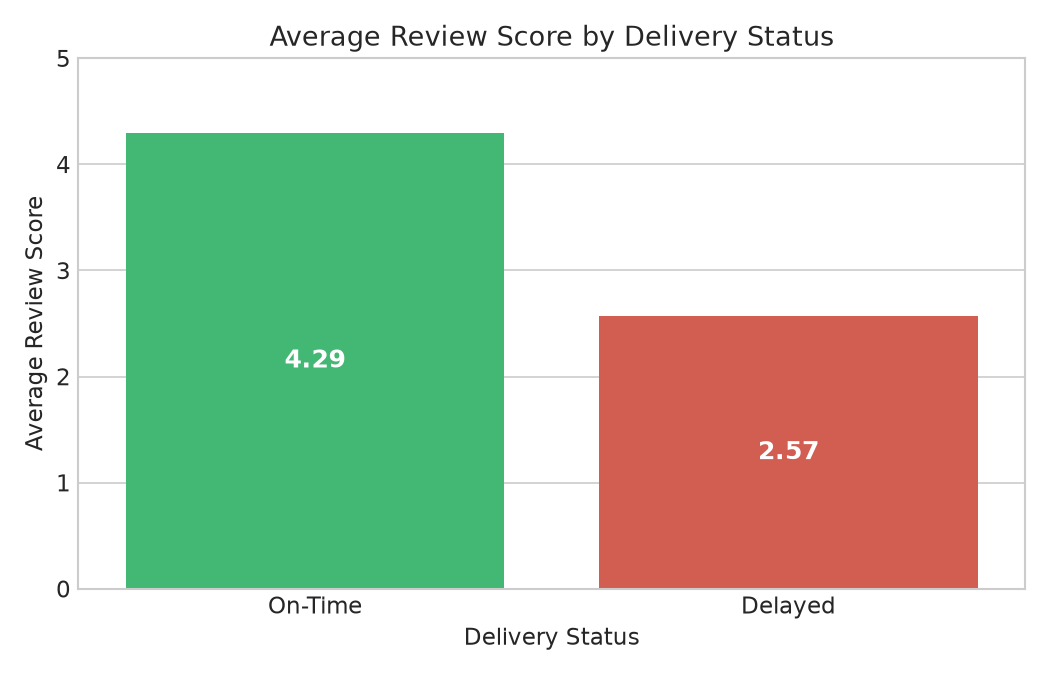

In [3]:
plt.figure(figsize=(7, 4.5))
palette = {'On-Time': '#2ecc71', 'Delayed': '#e74c3c'}
ax = sns.barplot(data=df, x='delivery_status', y='review_score', palette=palette, estimator='mean', errorbar=None)
plt.title('Average Review Score by Delivery Status')
plt.ylim(0, 5)
plt.ylabel('Average Review Score')
plt.xlabel('Delivery Status')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

## 3. Delivery Days Distribution

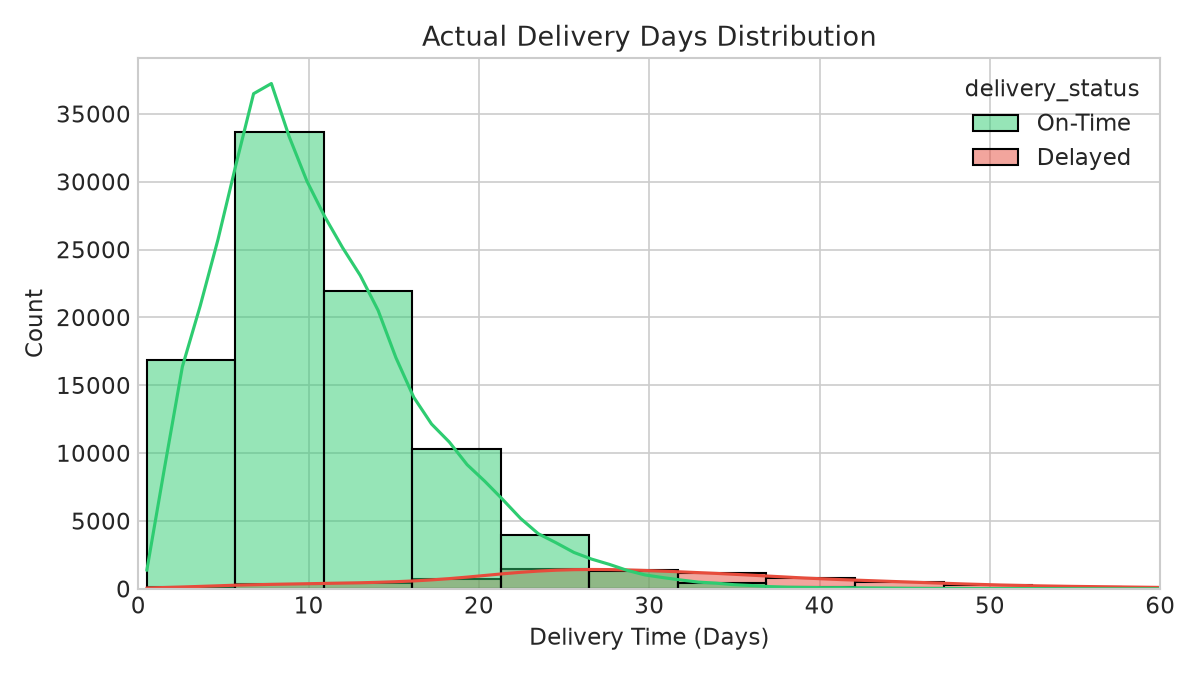

In [4]:
plt.figure(figsize=(8, 4.5))
sns.histplot(data=df, x='actual_delivery_days', hue='delivery_status', palette=palette, bins=40, kde=True, common_norm=False)
plt.xlim(0, 60)
plt.title('Actual Delivery Days Distribution')
plt.xlabel('Delivery Time (Days)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 4. Save Cleaned Data

In [5]:
output_csv = os.path.join(base_dir, 'Data', 'cleaned_delivery_analysis.csv')
df.to_csv(output_csv, index=False)
print('Cleaned dataset saved successfully to Data/cleaned_delivery_analysis.csv')

Cleaned dataset saved successfully to Data/cleaned_delivery_analysis.csv
